# Notebook 2 - Nutrition Scoring (4-Chain Sat Fat Analysis)
CSE 3104 Final Project | Andrew, Imaan, Juliet | April 2026

---

pulls nutrition data for 4 chains (McDonald's, Burger King, Wendy's, Carl's Jr), combines them into one file, and scores each chain by mean saturated fat. chains are split into two tiers since we only have 4 — bottom half is Tier 1 (healthiest), top half is Tier 2.

inputs: data/fastfood_calories.csv, data/wendys_dfin.csv, Nutritionix API
outputs: data/four_chain_nutrition.csv, outputs/four_chain_scores.csv, outputs/four_chain_satfat.png

In [23]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import os

DATA_DIR = 'data'
OUTPUT_DIR = 'outputs'
os.makedirs(OUTPUT_DIR, exist_ok=True)

## Load Carl's Jr Data

loads carlsjr_nutrition.csv from the data folder.

In [ ]:
carlsjr = pd.read_csv(os.path.join(DATA_DIR, 'carlsjr_nutrition.csv'))
carlsjr['restaurant'] = 'Carls Jr'

# carls jr has no category column so we use keyword matching on item names
# drop breakfast items, shakes, and fries — only burgers and chicken overlap with the other chains
breakfast_keywords = ['biscuit', 'egg', 'sausage', 'breakfast']
shake_keywords     = ['shake']
sides_keywords     = ['fries']

exclude_pattern = '|'.join(breakfast_keywords + shake_keywords + sides_keywords)
carlsjr = carlsjr[~carlsjr['item'].str.lower().str.contains(exclude_pattern)]
carlsjr = carlsjr.reset_index(drop=True)

print(f'loaded carlsjr_nutrition.csv: {len(carlsjr)} rows after dropping breakfast/shakes/fries')
print(carlsjr['item'].tolist())

loaded data/carlsjr_nutrition.csv (25 rows)


,restaurant,item,calories,sat_fat,total_fat,sodium,protein
0,Carls Jr,Famous Star with Cheese,660,13,39,1300,27
1,Carls Jr,Super Star with Cheese,920,23,58,1640,47
2,Carls Jr,Western Bacon Cheeseburger,710,13,33,1410,32


## Filter Kaggle Data to McDonald's and Burger King

loads fastfood_calories.csv and keeps only the two chains we want, trimmed down to the shared schema columns.

In [25]:
kaggle_raw = pd.read_csv(os.path.join(DATA_DIR, 'fastfood_calories.csv'), index_col=0)
kaggle_raw['restaurant'] = kaggle_raw['restaurant'].str.strip()

target_chains = ['Mcdonalds', 'Burger King']
kaggle_filtered = kaggle_raw[kaggle_raw['restaurant'].isin(target_chains)].copy()

# drop salads — the salad column flags items that don't exist at burger/chicken-focused chains
# keeping them would unfairly lower sat_fat averages for chains with more salad options
kaggle_filtered = kaggle_filtered[kaggle_filtered['salad'] != 1]

schema_cols = ['restaurant', 'item', 'calories', 'sat_fat', 'total_fat', 'sodium', 'protein']
kaggle_filtered = kaggle_filtered[schema_cols].reset_index(drop=True)

print(f'filtered to {len(kaggle_filtered)} rows across {kaggle_filtered["restaurant"].nunique()} chains (salads removed)')
print(kaggle_filtered['restaurant'].value_counts().to_string())

filtered to 127 rows across 2 chains (salads removed)
restaurant
Burger King    70
Mcdonalds      57


## Load Wendy's Data

loads wendys-menu.csv and prints the columns so we can confirm the rename map is correct.

In [26]:
wendys_raw = pd.read_csv(os.path.join(DATA_DIR, 'wendys-menu.csv'))

print('wendys-menu.csv columns:')
print(list(wendys_raw.columns))
print(f'{len(wendys_raw)} rows')
wendys_raw.head(3)

wendys-menu.csv columns:
['Item', 'Category', 'Calories', 'Fat (g)', 'Sat Fat (g)', 'Trans Fat (g)', 'Cholesterol (mg)', 'Sodium (mg)', 'Total Carb (g)', 'Dietary Fiber (g)', 'Sugars (g)', 'Protein (g)', 'Weight Watchers']
43 rows


,Item,Category,Calories,Fat (g),Sat Fat (g),Trans Fat (g),Cholesterol (mg),Sodium (mg),Total Carb (g),Dietary Fiber (g),Sugars (g),Protein (g),Weight Watchers
0,Baconator,Burgers,950,62,24.0,3.0,205,1630,40,2,8,59,923
1,Dave’s Double,Burgers,810,51,20.0,3.0,175,1280,41,3,8,49,789
2,Dave’s Single,Burgers,570,34,13.0,1.5,100,1110,40,3,9,30,562


## Remap Wendy's Columns

renames Wendy's columns to match the shared schema. update the rename map below if the actual column names differ from what the print above shows.

In [27]:
col_map = {
    'Item':          'item',
    'Calories':      'calories',
    'Sat Fat (g)':   'sat_fat',
    'Fat (g)':       'total_fat',
    'Sodium (mg)':   'sodium',
    'Protein (g)':   'protein',
}

wendys = wendys_raw.rename(columns=col_map)
wendys['restaurant'] = 'Wendys'

# drop breakfast items — other chains in this dataset don't have breakfast represented
# keeping them would bias wendys sat_fat upward since breakfast items tend to be high in fat
wendys = wendys[wendys_raw['Category'] != 'Breakfast']

schema_cols = ['restaurant', 'item', 'calories', 'sat_fat', 'total_fat', 'sodium', 'protein']
available = [c for c in schema_cols if c in wendys.columns]
wendys = wendys[available].reset_index(drop=True)

print(f'wendys: {len(wendys)} rows after dropping Breakfast (Burgers + Chicken only)')
print(f'columns: {list(wendys.columns)}')

wendys: 26 rows after dropping Breakfast (Burgers + Chicken only)
columns: ['restaurant', 'item', 'calories', 'sat_fat', 'total_fat', 'sodium', 'protein']


## Combine All Four Chains

stacks all four datasets. by this point each has already been filtered to overlapping item types — salads removed from McDonald's and Burger King, Breakfast removed from Wendy's — so the sat_fat comparison is across comparable menu items only.

In [28]:
schema_cols = ['restaurant', 'item', 'calories', 'sat_fat', 'total_fat', 'sodium', 'protein']

combined = pd.concat([kaggle_filtered, wendys, carlsjr], ignore_index=True)

# drop rows where sat_fat is missing since thats our scoring column
combined = combined.dropna(subset=['sat_fat'])
combined = combined[schema_cols].reset_index(drop=True)

combined.to_csv(os.path.join(DATA_DIR, 'four_chain_nutrition.csv'), index=False)
print(f'saved data/four_chain_nutrition.csv ({len(combined)} rows)')
print(combined['restaurant'].value_counts().to_string())

saved data/four_chain_nutrition.csv (178 rows)
restaurant
Burger King    70
Mcdonalds      57
Wendys         26
Carls Jr       25


## Score and Assign Tiers

calculates mean sat_fat per restaurant, ranks them lowest to highest, and splits into two tiers since we only have 4 chains.

In [29]:
four_chain = pd.read_csv(os.path.join(DATA_DIR, 'four_chain_nutrition.csv'))

scores = (
    four_chain.groupby('restaurant')['sat_fat']
    .agg(mean_sat_fat='mean', item_count='count')
    .round(4)
    .reset_index()
    .sort_values('mean_sat_fat')
    .reset_index(drop=True)
)

scores['rank'] = range(len(scores))

# with 4 chains, split in half instead of thirds
half = len(scores) // 2
scores['tier'] = scores['rank'].apply(lambda r: 'Tier 1' if r < half else 'Tier 2')

scores.to_csv(os.path.join(OUTPUT_DIR, 'four_chain_scores.csv'), index=False)
print(f'saved outputs/four_chain_scores.csv')
print()
print(scores[['restaurant', 'mean_sat_fat', 'item_count', 'tier']].to_string(index=False))

saved outputs/four_chain_scores.csv

 restaurant  mean_sat_fat  item_count   tier
     Wendys        7.9808          26 Tier 1
  Mcdonalds        8.2895          57 Tier 1
Burger King       11.1500          70 Tier 2
   Carls Jr       12.3600          25 Tier 2


## Plot

bar chart of mean sat_fat per restaurant, green for Tier 1, red for Tier 2. saves to outputs/four_chain_satfat.png.

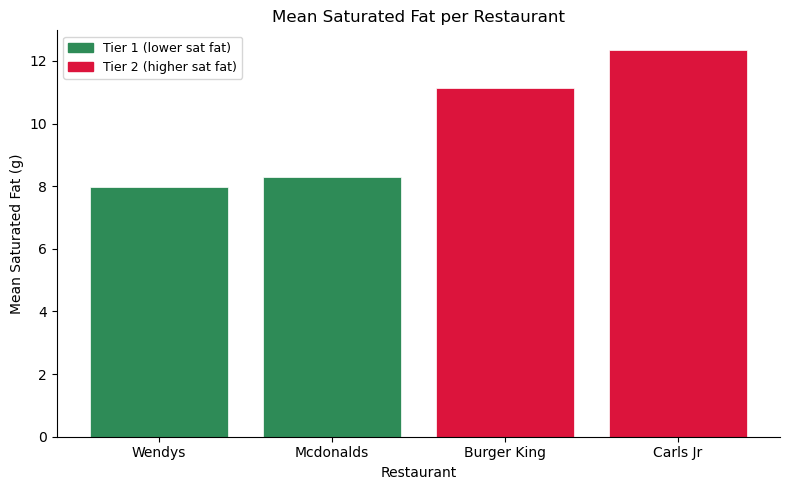

saved outputs/four_chain_satfat.png


In [30]:
tier_colors = {'Tier 1': 'seagreen', 'Tier 2': 'crimson'}
bar_colors = scores['tier'].map(tier_colors)

fig, ax = plt.subplots(figsize=(8, 5))

ax.bar(
    scores['restaurant'],
    scores['mean_sat_fat'],
    color=bar_colors,
    edgecolor='white',
    linewidth=0.5
)

ax.set_xlabel('Restaurant')
ax.set_ylabel('Mean Saturated Fat (g)')
ax.set_title('Mean Saturated Fat per Restaurant')

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.yaxis.grid(False)
ax.xaxis.grid(False)

legend_handles = [
    mpatches.Patch(color='seagreen', label='Tier 1 (lower sat fat)'),
    mpatches.Patch(color='crimson',  label='Tier 2 (higher sat fat)'),
]
ax.legend(handles=legend_handles, fontsize=9)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'four_chain_satfat.png'), dpi=150)
plt.show()
print('saved outputs/four_chain_satfat.png')